In [17]:
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

In [18]:
# Seed torch for reproducibility
import os, random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
# Load Data
# **IMPORTANT** Make sure ALL data files are either in the "Data" directory, or if stored locally, change path to local path
# spectra_data = np.load("G:\\Comp 562 Exoplanet Data Raw per 10000\\npy_outputs\\ALL_planet_spectra_combined.npy")
spectra_data = np.load("..\\data\\spectra_data_first_30000.npy")

wavelengths = pd.read_csv("..\\data\\wavelengths.csv", header=0).values.flatten().astype(np.float64)

#metadata = pd.read_csv("..\\PSG_models_all.csv")
metadata = pd.read_csv("..\\Data\\PSG_models_first_30000.csv")

In [21]:
# Filter wavelength to < 2.0 microns and extract signal
wavelength_mask = wavelengths <= 2.0
filtered_signals = spectra_data[:, wavelength_mask]

In [22]:
# Normalize spectral data
scaler = StandardScaler()
X = scaler.fit_transform(filtered_signals)

In [23]:
# Normalize H2O gas abundance data
h2o_abundance = metadata['H2O'].values
Y = np.log10(h2o_abundance + 1e-8)

# Clean NaNs
mask = (~np.isnan(X).any(axis=1)) & (~np.isnan(Y))
X = X[mask]
Y = Y[mask]

In [24]:
# Train/val/test split
# If running on the full dataset of 300k, splits should be:
#   - Training set: 272,700     ~ 90.9% of the dataset
#   - Validation set: 24,800    ~ 8.27% 
#   - Testing set: 2,500        ~ 0.83%
# If not, still use same percentage based splits
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, train_size=(272700 / 300000), random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=(2500 / 27300), train_size=(24800 / 27300), random_state=42)

In [25]:
# Dataset
class SpectraDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [26]:
# CNN
# Architecture: Conv1d(64)-tanh-MaxPool-Conv1d(64)-relu-MaxPool-Conv1d(128)-reluMaxPool-Conv1d(256)-relu-FC(256)-relu-FC(12)
class SpectraNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, seq_len)
        x = self.cnn(x)
        return self.fc(x)

In [27]:
# Learning Rate Finder (Currently commented as it has already been ran)

#from torch_lr_finder import LRFinder

#train_loader = DataLoader(SpectraDataset(X_train, Y_train), batch_size=64, shuffle=True)

#lr_model = SpectraNet(X_train.shape[1]).to(device)
#lr_optimizer = optim.Adam(lr_model.parameters(), lr=1e-7)
#lr_criterion = nn.MSELoss()
#lr_finder = LRFinder(lr_model, lr_optimizer, lr_criterion, device=device)
#lr_finder.range_test(train_loader, end_lr=1, num_iter=100, step_mode='exp')
#lr_finder.plot(log_lr=True)
#lr_finder.reset()

In [28]:
# Prepare loaders
train_loader = DataLoader(SpectraDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(SpectraDataset(X_val, Y_val), batch_size=64)
test_data = torch.tensor(X_test, dtype=torch.float32)
test_targets = torch.tensor(Y_test, dtype=torch.float32)

In [29]:
# Model setup and hyperparameter preparation
# Current parameters:
#   - Optimizer: Adam
#   - Loss: MSE
#   - Learning-rate: 6.58e-4 (Found via torch's LRFinder) with lr_scheduler utilization
#   - Batch-size: 64 (Can go up to 128 to save some time, but not recommended for bet results)
#   - Epochs: 150 (Realistically could go down to 100, but found best results at 150 using early stopping)
#   - Uses GradScaler() and autocast for better performance on GPU.
model = SpectraNet(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=6.58e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
scaler = GradScaler()

In [30]:
# Training the Model
# Tracks validation vs training loss to determine if/when early stoppage criteria is met
# Current patience is set to 10 epochs
best_val_loss = float('inf')
patience = 10
counter = 0

train_losses, val_losses = [], []

for epoch in range(150):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with autocast(device_type=device.type):
            preds = model(x)
            loss = criterion(preds, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * x.size(0)
    
    avg_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_loss += criterion(model(x), y).item() * x.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    # Displays training and validation loss for each epoch
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "..\\Saved-models\\best_model_h2o_mc_dropout.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early Stopping Triggered at Epoch {epoch+1:02d}")
            break
        

Epoch 01 | Train Loss: 0.26677 | Val Loss: 0.20223
Epoch 02 | Train Loss: 0.21239 | Val Loss: 0.20412
Epoch 03 | Train Loss: 0.21298 | Val Loss: 0.20386
Epoch 04 | Train Loss: 0.21114 | Val Loss: 0.20462
Epoch 05 | Train Loss: 0.21274 | Val Loss: 0.20219
Epoch 06 | Train Loss: 0.21034 | Val Loss: 0.20687
Epoch 07 | Train Loss: 0.20990 | Val Loss: 0.20236
Epoch 08 | Train Loss: 0.20982 | Val Loss: 0.20220


KeyboardInterrupt: 

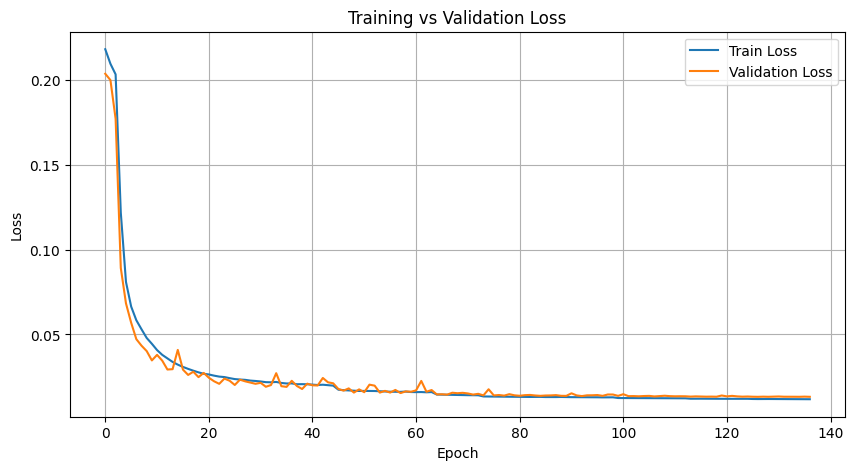

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Monte Carlo Dropout Evaluation
# Evaluates CNN using Monte Carlo dropout with 600 forward passes
# Final prediction is the mean of 600 predictions for each sample
model.load_state_dict(torch.load("..\\Saved-models\\best_model_h2o_mc_dropout.pth"))
model.eval()

def enable_dropout(m):
    if type(m) == nn.Dropout:
        m.train()

model.apply(enable_dropout)

SpectraNet(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Tanh()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [ ]:
# Normalize targets for figure
# Data is normalized by subtracting the mean from the data and dividing by standard deviation
mu = Y.mean()
sigma = Y.std()
test_targets_norm = ((test_targets - mu) / sigma).numpy()

all_preds = []
with torch.no_grad():
    for _ in range(600):
        preds = model(test_data.to(device)).cpu().numpy().flatten()
        preds_norm = (preds - mu) / sigma
        all_preds.append(preds_norm)

mc_mean = np.mean(all_preds, axis=0)

In [ ]:
# Evaluation Metrics for model performance
mse = mean_squared_error(test_targets_norm, mc_mean)
r2 = 1 - (np.sum((test_targets_norm - mc_mean) ** 2) / np.sum((test_targets_norm - np.mean(test_targets_norm)) ** 2))
print(f"Final Test MSE (normalized): {mse:.5f}")
print(f"Final Test R^2 (normalized): {r2:.5f}")

0.9472804491989982
Final Test MSE (normalized): 0.05747
Final Test R^2 (normalized): 0.94728


In [ ]:
# Display first 20 Predictions vs Actual (logged and normalized)
print(f"First 20 Predictions vs True Values (normalized):")
for i in range(20):
    print(f"Predicted: {mc_mean[i]:.4f} | True: {test_targets_norm[i]:.4f}")

First 20 Predictions vs True Values (normalized):
Predicted: 0.4185 | True: 0.4142
Predicted: 0.7484 | True: 0.7873
Predicted: 0.0237 | True: 0.0304
Predicted: -0.2100 | True: 0.1792
Predicted: 1.1196 | True: 1.1704
Predicted: 0.1246 | True: 0.2142
Predicted: 0.7056 | True: 0.8979
Predicted: 0.1073 | True: 0.3573
Predicted: -0.8088 | True: -0.9077
Predicted: 0.5678 | True: 0.9973
Predicted: -0.3118 | True: -0.2191
Predicted: 0.7782 | True: 0.5130
Predicted: -0.8867 | True: -0.9149
Predicted: 0.3475 | True: 0.0747
Predicted: 0.5968 | True: 0.4653
Predicted: -0.7941 | True: -0.5069
Predicted: 0.5605 | True: 0.4981
Predicted: -0.9375 | True: -1.0887
Predicted: -0.5944 | True: -0.8177
Predicted: 0.6035 | True: 0.6026


In [ ]:
# Prints the first 20 predicted vs actual un-logged and un-normalized test samples
mc_mean_unnorm = mc_mean[:] * sigma + mu

print("First 20 Predicted vs Actual Un-Logged and Un-Normalized")

for i in range(20):
    print(f"Predicted: {(10 ** mc_mean_unnorm[i] - 1e-8):.6f} | True: {(10 ** test_targets[i] - 1e-8):.6f}")


First 20 Predicted vs Actual Un-Logged and Un-Normalized
Predicted: 0.036701 | True: 0.036535
Predicted: 0.051772 | True: 0.053920
Predicted: 0.024311 | True: 0.024481
Predicted: 0.019051 | True: 0.028594
Predicted: 0.076257 | True: 0.080408
Predicted: 0.027008 | True: 0.029655
Predicted: 0.049514 | True: 0.060512
Predicted: 0.026526 | True: 0.034431
Predicted: 0.010201 | True: 0.009202
Predicted: 0.042887 | True: 0.067122
Predicted: 0.017132 | True: 0.018873
Predicted: 0.053412 | True: 0.040501
Predicted: 0.009405 | True: 0.009132
Predicted: 0.034080 | True: 0.025641
Predicted: 0.044201 | True: 0.038534
Predicted: 0.010360 | True: 0.013977
Predicted: 0.042559 | True: 0.039876
Predicted: 0.008920 | True: 0.007618
Predicted: 0.012758 | True: 0.010107
Predicted: 0.044512 | True: 0.044468


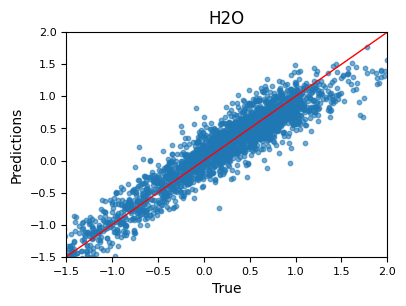

In [ ]:
# Plot of predictions vs actual
plt.figure(figsize=(4, 3))
plt.scatter(test_targets_norm, mc_mean, s=10, alpha=0.6)
plt.plot([-2, 2], [-2, 2], 'r-', linewidth=1)

plt.xlim(-1.5, 2)
plt.ylim(-1.5, 2)
plt.xlabel("True")
plt.ylabel("Predictions")
plt.title("H2O")

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(pad=0.5)
plt.show()

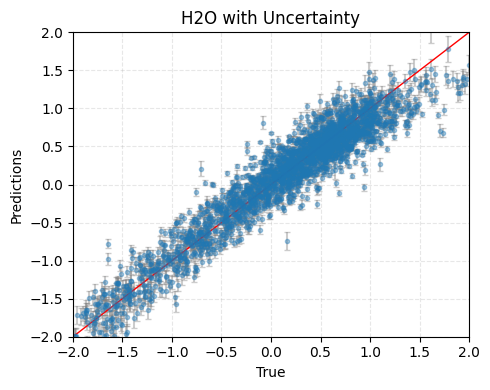

In [ ]:
# Plotting Predictions with Uncertainty 
mc_std = np.std(all_preds, axis=0)

plt.figure(figsize=(5, 4))
plt.errorbar(test_targets_norm, mc_mean, yerr=mc_std, fmt='o', alpha=0.4, markersize=3, ecolor='gray', capsize=2)
plt.plot([-2, 2], [-2, 2], 'r-', linewidth=1)
plt.xlabel("True")
plt.ylabel("Predictions")
plt.title("H2O with Uncertainty")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()